In [35]:
from pylib.preamble import *
enable_autoreload()

from pylib.fig_setup import PALETTE, STYLE, LW, style_ax, legend, country_handles

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
df_a = pd.read_parquet("0_intermediate/df_a.parquet")
df_m = pd.read_parquet("0_intermediate/df_m.parquet")

COUNTRIES = var_groups.countries

# Assess the `aggregate` and `parent` electrification rates 

Per the chosen countries in `var_groups.countries`, I plot the evolution since 1990 in electrification rates. This is merely descriptive statistics for the evolution, then we'll look into the reasons for the differences across times and between countries next.

### 1. Evolution over time absolute aggregate

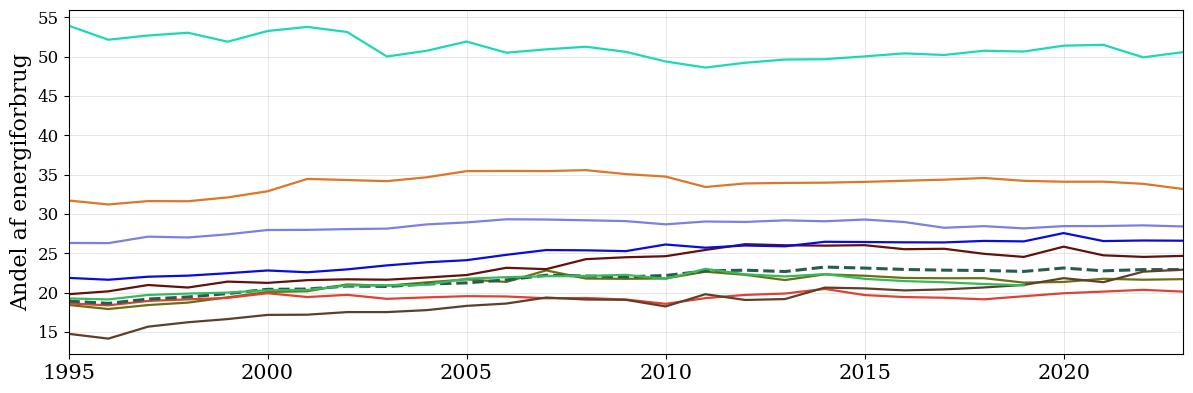

In [37]:
fig, ax = plt.subplots(figsize=(12, 4))

for geo, grp in df_a.groupby("geo"):
    grp = grp.sort_values("year")
    ax.plot(grp["year"], grp["value"],
            ls=STYLE[geo], color=PALETTE[geo], lw=LW[geo], label=geo)

style_ax(ax, df_a["year"])
ax.set_ylabel("Andel af energiforbrug")
# ax.set_title("Aggregate electrification rate")
# legend(ax, ncol=6, loc='center', bbox_to_anchor=(0.5,1.2))
plt.tight_layout()
plt.show()

### 2. Evolution over time indexed aggregate

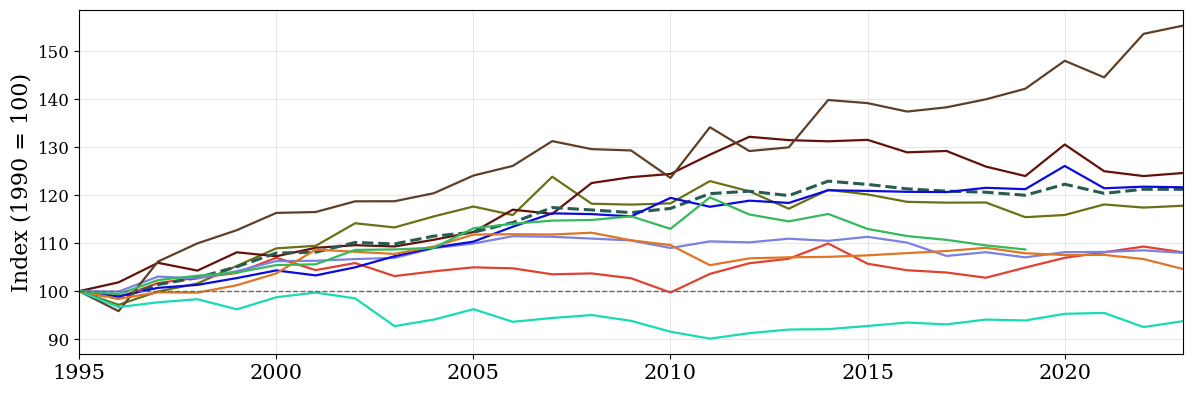

In [38]:
# Index each country to 1000 in 1990
base = df_a[df_a["year"] == 1995].set_index("geo")["value"]
df_a_idx = df_a.copy()
df_a_idx["value"] = df_a_idx.apply(lambda r: r["value"] / base[r["geo"]] * 100, axis=1)

fig, ax = plt.subplots(figsize=(12, 4))

for geo, grp in df_a_idx.groupby("geo"):
    grp = grp.sort_values("year")
    ax.plot(grp["year"], grp["value"],
            ls=STYLE[geo], color=PALETTE[geo], lw=LW[geo], label=geo)

ax.axhline(100, color="0.4", lw=1, ls="--")
style_ax(ax, df_a_idx["year"])
ax.set_ylabel("Index (1990 = 100)")
# legend(ax, ncol=4, loc='center', bbox_to_anchor=(0.5,1.2), handles=country_handles(COUNTRIES))
plt.tight_layout()
plt.show()

### 3. Evolution over time absolute parent industries

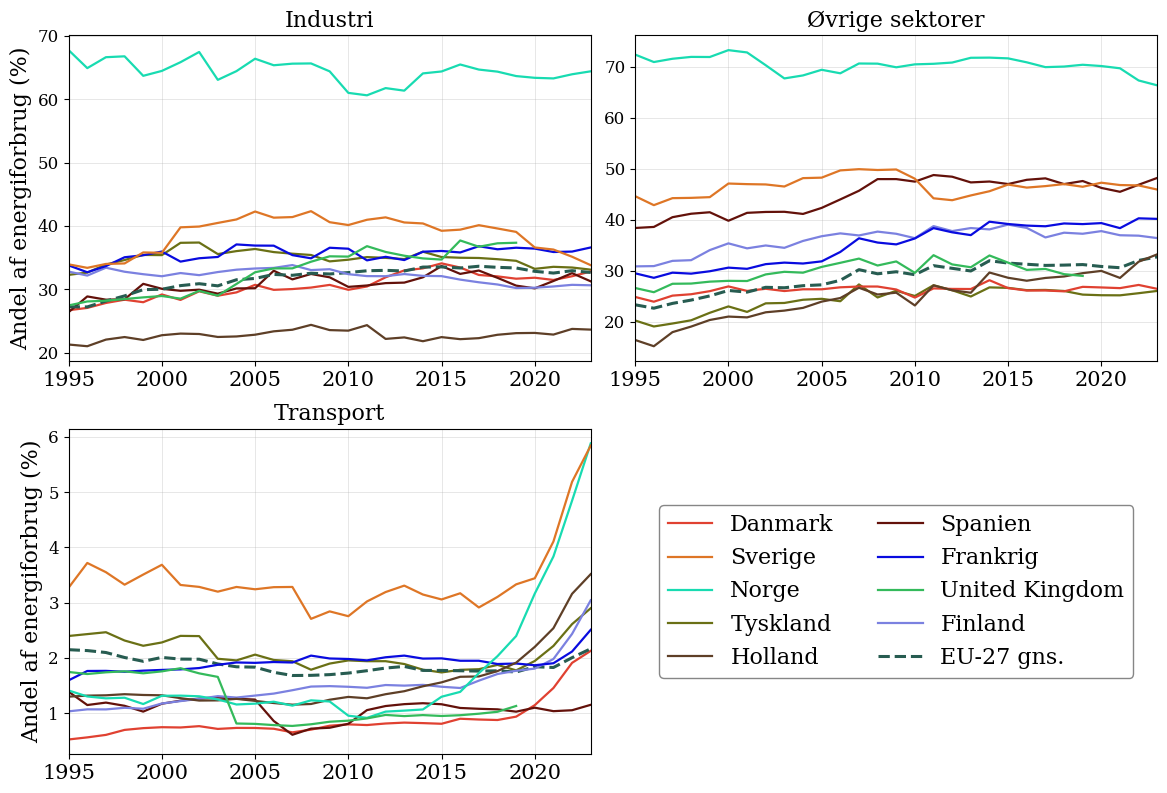

In [39]:
parents = list(df_m["nrg_bal"].unique())
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_axes = [axes[0, 0], axes[0, 1], axes[1, 0]]

for ax, nrg in zip(plot_axes, parents):
    sub = df_m[df_m["nrg_bal"] == nrg]
    for geo, grp in sub.groupby("geo"):
        grp = grp.sort_values("year")
        ax.plot(grp["year"], grp["value"],
                ls=STYLE[geo], color=PALETTE[geo], lw=LW[geo])
    style_ax(ax, sub["year"])
    ax.set_title(var_groups.labels[nrg])

# y-label only on left column
axes[0, 0].set_ylabel("Andel af energiforbrug (%)")
axes[1, 0].set_ylabel("Andel af energiforbrug (%)")

ax_leg = axes[1, 1]
ax_leg.axis("off")
ax_leg.legend(handles=country_handles(COUNTRIES), loc="center",
              frameon=True, framealpha=0.95, edgecolor="0.5", fancybox=True,
              ncol=2)

plt.tight_layout()
plt.show()

### 4. Evolution over time indexed parent industries

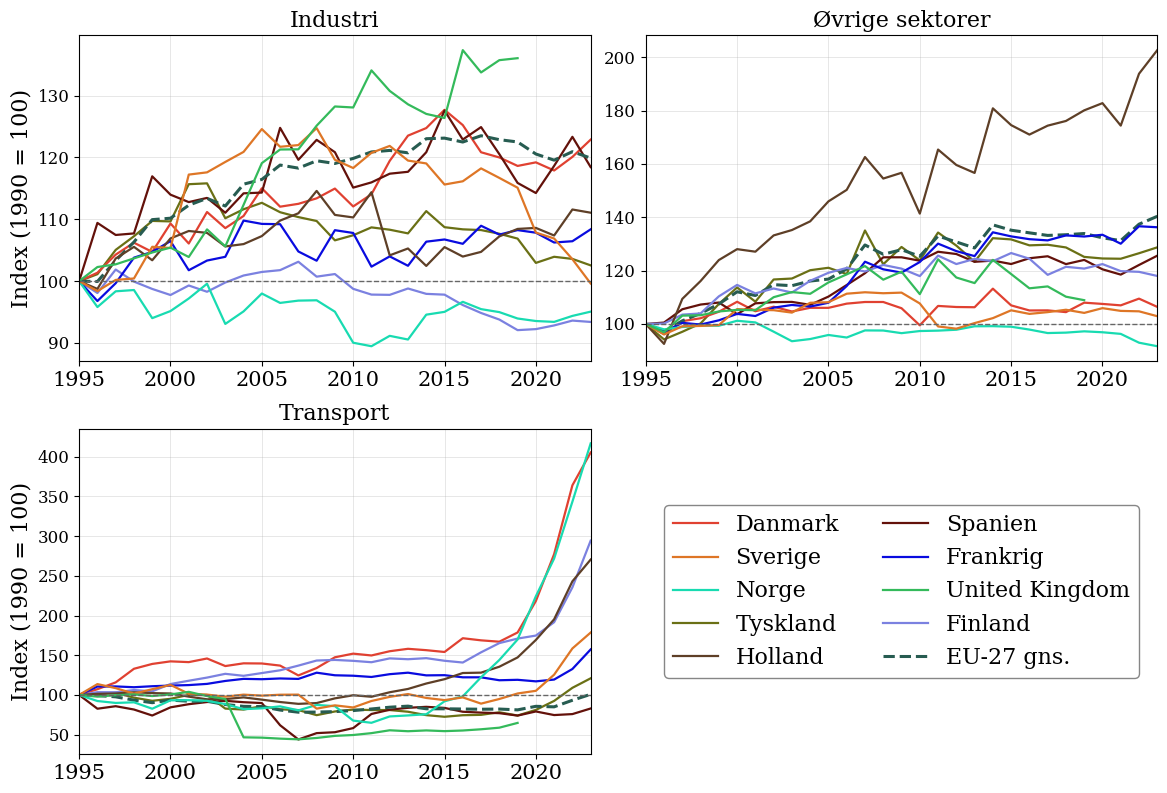

In [40]:
base_m = df_m[df_m["year"] == 1995].set_index(["geo", "nrg_bal"])["value"]
df_m_idx = df_m.copy()
df_m_idx["value"] = df_m_idx.apply(
    lambda r: r["value"] / base_m.get((r["geo"], r["nrg_bal"]), float("nan")) * 100, axis=1
)

parents = list(df_m_idx["nrg_bal"].unique())
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_axes = [axes[0, 0], axes[0, 1], axes[1, 0]]

for ax, nrg in zip(plot_axes, parents):
    sub = df_m_idx[df_m_idx["nrg_bal"] == nrg]
    for geo, grp in sub.groupby("geo"):
        grp = grp.sort_values("year")
        ax.plot(grp["year"], grp["value"],
                ls=STYLE[geo], color=PALETTE[geo], lw=LW[geo])
    ax.axhline(100, color="0.4", lw=1, ls="--")
    style_ax(ax, sub["year"])
    ax.set_title(var_groups.labels[nrg])

axes[0, 0].set_ylabel("Index (1990 = 100)")
axes[1, 0].set_ylabel("Index (1990 = 100)")

ax_leg = axes[1, 1]
ax_leg.axis("off")
ax_leg.legend(handles=country_handles(COUNTRIES), loc="center",
              frameon=True, framealpha=0.95, edgecolor="0.5", fancybox=True,
              ncol=2)

plt.tight_layout()
plt.show()

### 5. DK vs. EU-avg. per sub industries

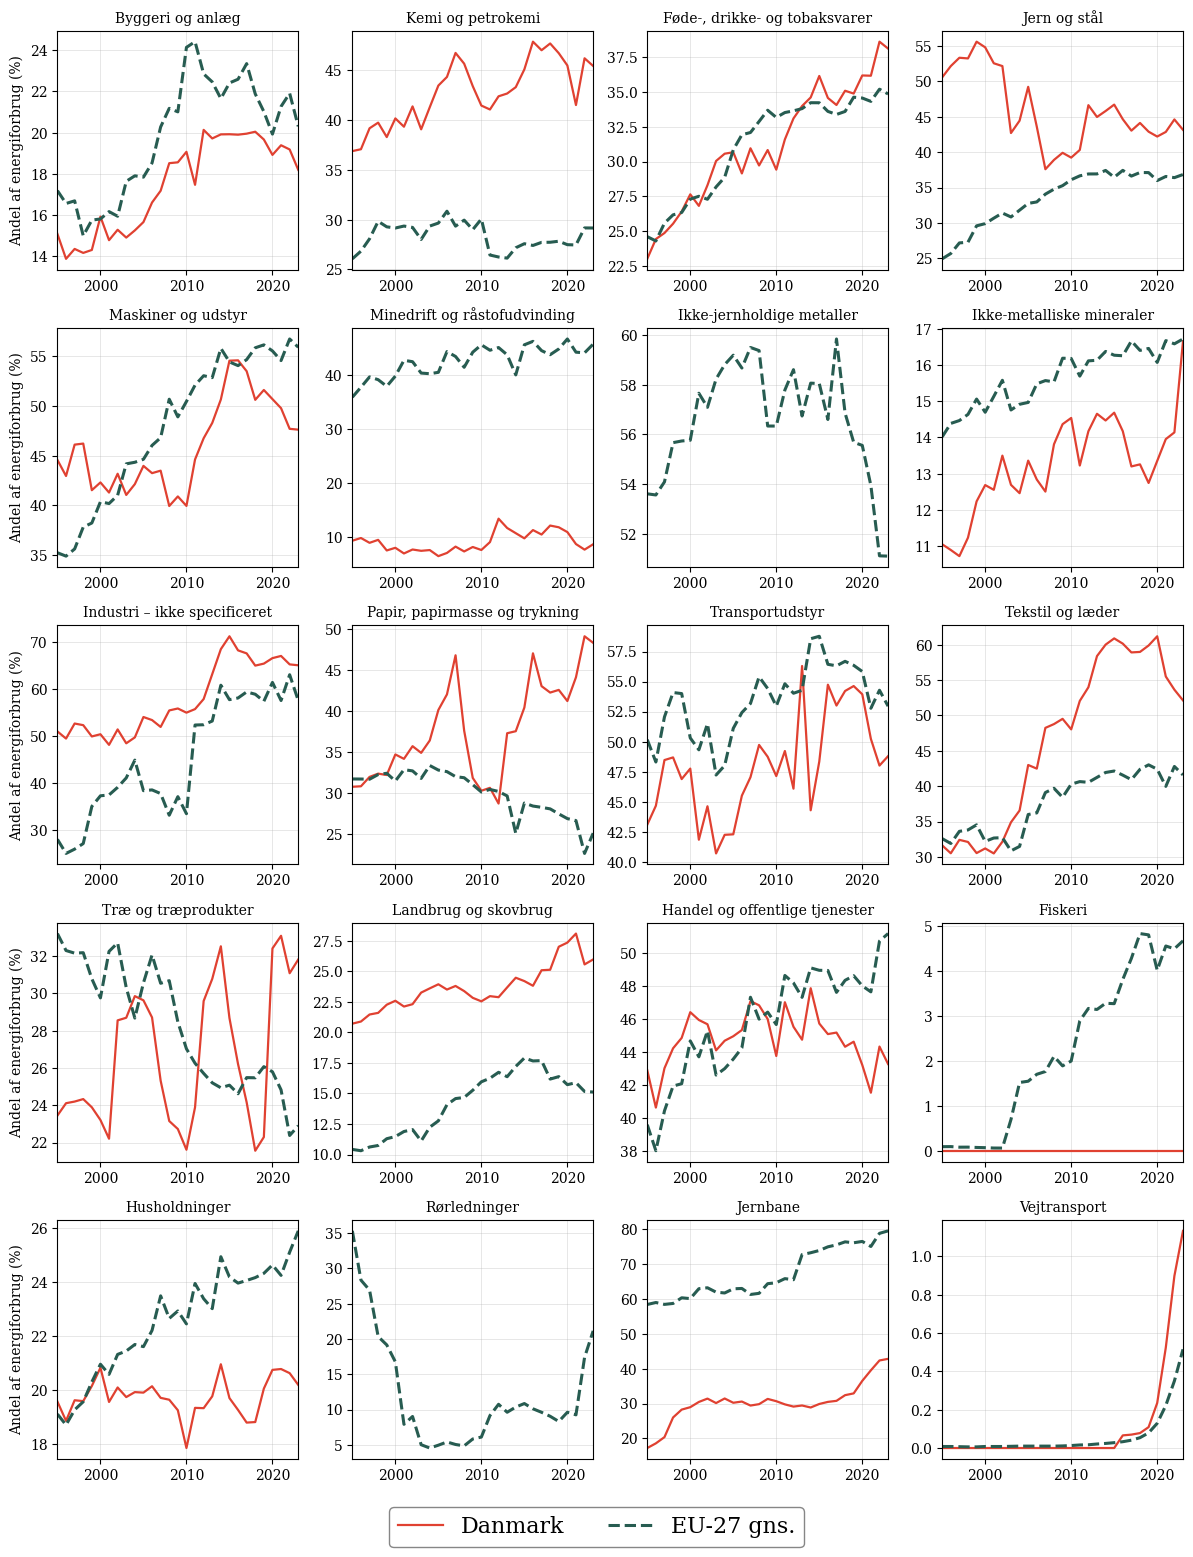

In [41]:
df_s = pd.read_parquet("0_intermediate/df_s.parquet")

DROP_SECTORS = ['FC_TRA_DAVI_E', 'FC_TRA_DNAVI_E', 'FC_TRA_NSP_E', 'FC_OTH_NSP_E']
GEO_SUB = ["DK", "EU27_2020"]

sub_data = df_s[df_s["geo"].isin(GEO_SUB) & ~df_s["nrg_bal"].isin(DROP_SECTORS)]
sectors  = list(sub_data["nrg_bal"].unique())

NCOLS = 4
NROWS = -(-len(sectors) // NCOLS)

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(12, 3.0 * NROWS))
axes_flat = axes.flatten()

for i, (ax, nrg) in enumerate(zip(axes_flat, sectors)):
    sub = sub_data[sub_data["nrg_bal"] == nrg]
    for geo, grp in sub.groupby("geo"):
        grp = grp.sort_values("year")
        ax.plot(grp["year"], grp["value"],
                ls=STYLE[geo], color=PALETTE[geo], lw=LW[geo], label=geo)
    style_ax(ax, sub["year"], step=10)
    ax.set_title(var_groups.labels[nrg], fontsize=10)
    ax.tick_params(labelsize=10)
    if i % NCOLS == 0:
        ax.set_ylabel("Andel af energiforbrug (%)", fontsize=10)

for ax in axes_flat[len(sectors):]:
    ax.axis("off")

fig.legend(handles=country_handles(GEO_SUB), loc="upper center",
           bbox_to_anchor=(0.5, 0), ncol=len(GEO_SUB),
           frameon=True, framealpha=0.95, edgecolor="0.5", fancybox=True)

plt.tight_layout()
plt.show()